# 📊 Complete EDA Notebook for MSC Stem Cell Dataset

# 1️⃣ Import Required Libraries

In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.rcParams['figure.figsize'] = (8,5)
sns.set_style("whitegrid")

# 2️⃣ Load Dataset

In [2]:
# Load the dataset
df = pd.read_excel("msc_stem_cell_dataset_5000_samples.xlsx")

# Preview data
df.head()

,Temperature_C,pH,CO2_%,O2_%,Humidity_%,Glucose_g_L,Glutamine_mM,Serum_%,GrowthFactor_ng_mL,SeedingDensity_cells_cm2,Passage_Number,Culture_Duration_days,MediumChange_days,Initial_Viability_%,Final_Viability_%,Morphology_Score,Contamination_Risk,Confluence_%,Doubling_Time_hours,Stem Cell Count
0,36.4,7.1,5.8,17.0,87.4,5.2,2.8,6.9,16.3,9118.1,5.7,1.9,1.6,89.1,99.4,0.8,NaN,91.7,21.2,15150.3
1,37.6,7.2,4.1,22.2,90.7,3.5,1.8,10.5,8.4,NaN,7.3,6.1,2.5,91.9,97.9,0.6,NaN,78.7,20.2,10623.6
2,36.6,7.3,6.0,23.0,93.9,4.7,1.6,12.0,24.7,NaN,4.6,3.2,2.6,95.2,NaN,0.6,0.1,66.1,30.0,12110.0
3,37.9,7.1,5.4,19.2,86.7,3.2,1.5,10.6,19.4,1090.7,1.9,5.4,1.7,82.7,86.4,0.8,0.1,55.9,20.8,6652.9
4,36.7,7.1,4.8,NaN,97.7,3.1,2.4,13.4,28.8,8586.7,3.6,7.2,2.2,83.1,80.7,0.6,0.1,81.5,15.8,12921.3


# 3️⃣ Basic Structure Analysis

In [3]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types
df.dtypes

Dataset Shape: (5000, 20)

Columns:
 Index(['Temperature_C', 'pH', 'CO2_%', 'O2_%', 'Humidity_%', 'Glucose_g_L',
       'Glutamine_mM', 'Serum_%', 'GrowthFactor_ng_mL',
       'SeedingDensity_cells_cm2', 'Passage_Number', 'Culture_Duration_days',
       'MediumChange_days', 'Initial_Viability_%', 'Final_Viability_%',
       'Morphology_Score', 'Contamination_Risk', 'Confluence_%',
       'Doubling_Time_hours', 'Stem Cell Count'],
      dtype='object')


,0
Temperature_C,float64
pH,float64
CO2_%,float64
O2_%,float64
Humidity_%,float64
Glucose_g_L,float64
Glutamine_mM,float64
Serum_%,float64
GrowthFactor_ng_mL,float64
SeedingDensity_cells_cm2,float64


# 4️⃣ Missing Value Analysis

In [4]:
# Missing values
missing_values = df.isnull().sum()

missing_values

,0
Temperature_C,370
pH,301
CO2_%,312
O2_%,371
Humidity_%,348
Glucose_g_L,338
Glutamine_mM,290
Serum_%,360
GrowthFactor_ng_mL,338
SeedingDensity_cells_cm2,381


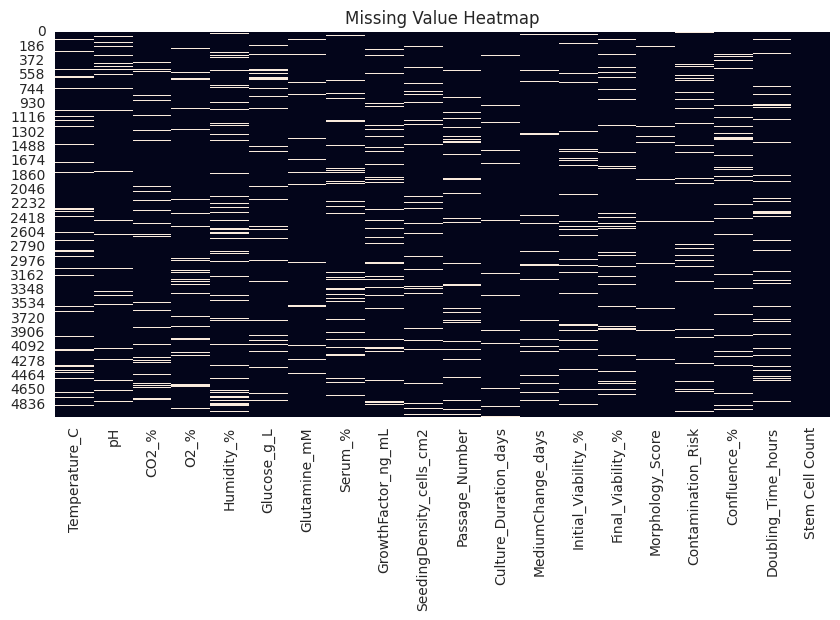

In [5]:
#Visualization:

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

# 5️⃣ Duplicate Data Check

In [6]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


# 6️⃣ Biological Range Validation

Check biologically valid ranges.

In [7]:
# Temperature
temp_out = df[(df['Temperature_C'] < 35) | (df['Temperature_C'] > 39)]

# pH
ph_out = df[(df['pH'] < 7.0) | (df['pH'] > 7.6)]

# Viability
viability_out = df[(df['Initial_Viability_%'] < 80) | (df['Initial_Viability_%'] > 105)]

print("Temperature Outliers:", len(temp_out))
print("pH Outliers:", len(ph_out))
print("Viability Outliers:", len(viability_out))

Temperature Outliers: 0
pH Outliers: 0
Viability Outliers: 23


# 7️⃣ Summary Statistics

In [8]:
df.describe()

,Temperature_C,pH,CO2_%,O2_%,Humidity_%,Glucose_g_L,Glutamine_mM,Serum_%,GrowthFactor_ng_mL,SeedingDensity_cells_cm2,Passage_Number,Culture_Duration_days,MediumChange_days,Initial_Viability_%,Final_Viability_%,Morphology_Score,Contamination_Risk,Confluence_%,Doubling_Time_hours,Stem Cell Count
count,4630.000000,4699.000000,4688.000000,4629.000000,4652.000000,4662.000000,4710.000000,4640.000000,4662.000000,4619.000000,4624.000000,4731.000000,4764.000000,4710.000000,4655.000000,4740.000000,4686.000000,4544.000000,4618.000000,5000.0000
mean,36.978143,7.286976,5.030930,19.500583,92.315821,4.495882,1.991295,9.838728,14.620764,5583.366508,4.893426,4.476390,2.224475,92.348641,89.619656,0.742236,0.147397,69.742474,26.127155,10585.6727
std,0.890463,0.173661,0.596897,2.573695,4.218581,0.884072,0.576370,2.917945,8.434988,2621.961529,2.828659,2.031877,0.997373,7.230440,5.684907,0.151300,0.093438,16.129020,7.815949,2372.7196
min,35.500000,7.000000,4.000000,14.900000,84.800000,2.900000,1.000000,5.000000,-0.400000,912.800000,0.000000,0.900000,0.500000,79.800000,79.800000,0.500000,0.000000,39.400000,11.600000,5513.3000
25%,36.200000,7.100000,4.500000,17.300000,89.000000,3.700000,1.500000,7.300000,7.100000,3233.500000,2.600000,2.700000,1.400000,86.100000,84.700000,0.600000,0.100000,56.500000,19.800000,8733.5000
50%,37.000000,7.300000,5.100000,19.600000,92.100000,4.500000,2.100000,9.700000,15.100000,5522.700000,4.800000,4.500000,2.300000,91.800000,89.600000,0.700000,0.100000,70.300000,26.000000,10527.0000
75%,37.700000,7.400000,5.600000,21.700000,95.800000,5.300000,2.500000,12.500000,21.000000,7948.300000,7.200000,6.200000,3.000000,99.100000,94.100000,0.900000,0.200000,81.900000,32.700000,12460.9000
max,38.500000,7.600000,6.000000,24.100000,100.000000,6.000000,3.000000,15.200000,30.200000,10045.600000,10.100000,8.100000,4.000000,105.400000,100.300000,1.000000,0.300000,100.200000,40.100000,16224.3000


# 📊 UNIVARIATE ANALYSIS


#8️⃣ Histograms of Key Environmental Variables

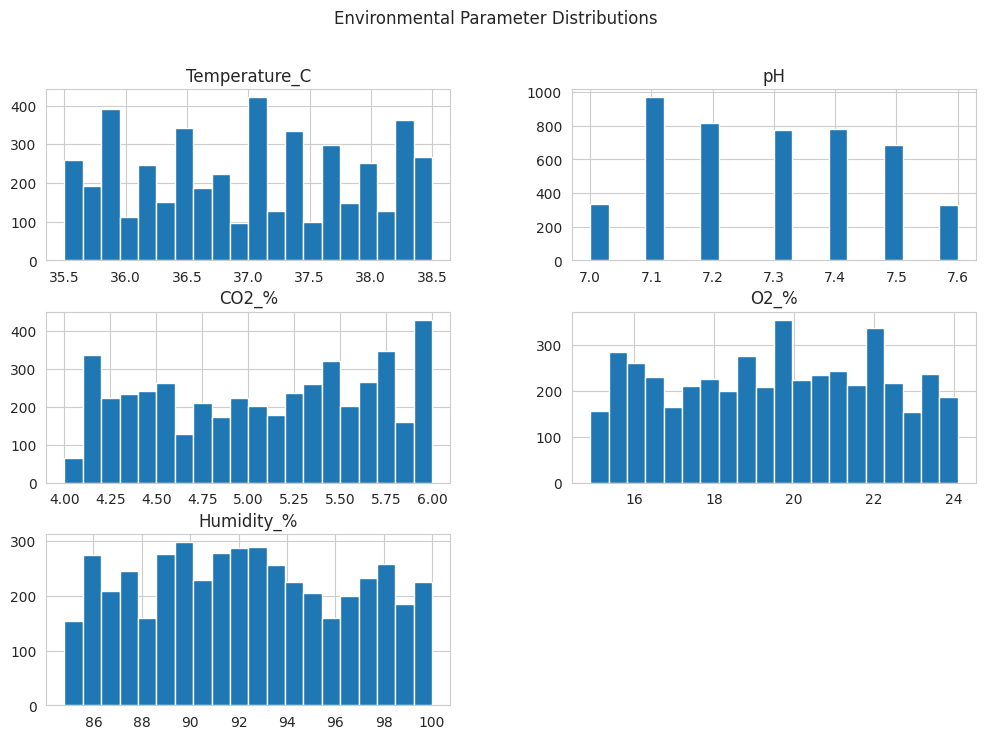

In [9]:
env_features = [
'Temperature_C',
'pH',
'CO2_%',
'O2_%',
'Humidity_%'
]

df[env_features].hist(bins=20, figsize=(12,8))

plt.suptitle("Environmental Parameter Distributions")
plt.show()

# 9️⃣ Nutrient Parameter Distributions

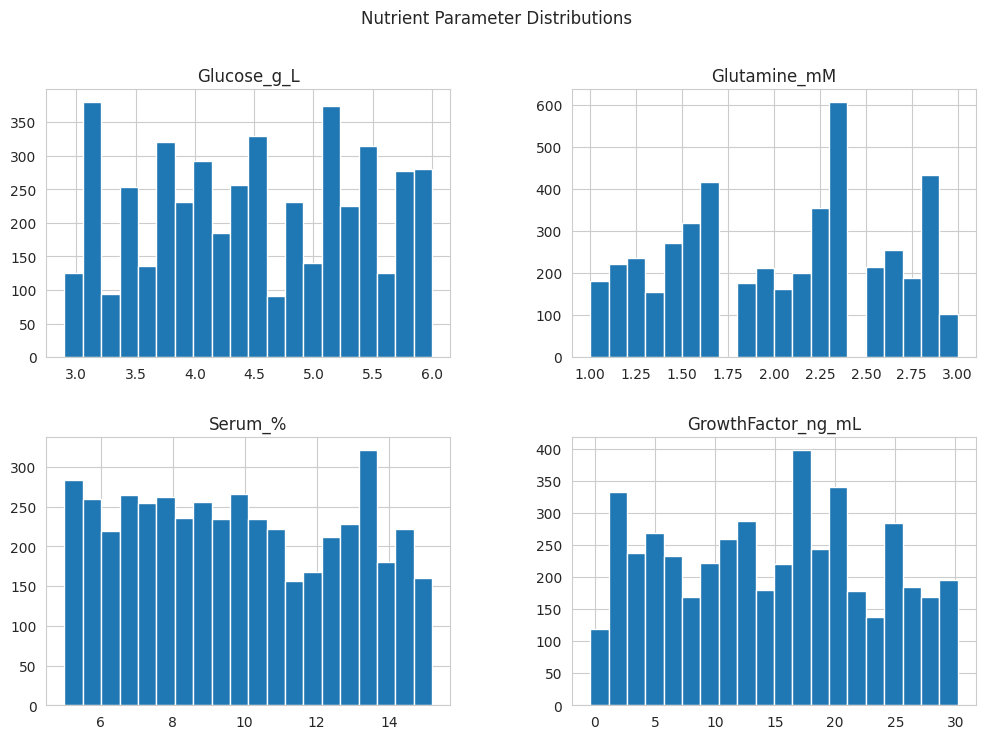

In [10]:
nutrient_features = [
'Glucose_g_L',
'Glutamine_mM',
'Serum_%',
'GrowthFactor_ng_mL'
]

df[nutrient_features].hist(bins=20, figsize=(12,8))
plt.suptitle("Nutrient Parameter Distributions")
plt.show()

# 🔟 Culture Parameter Distributions

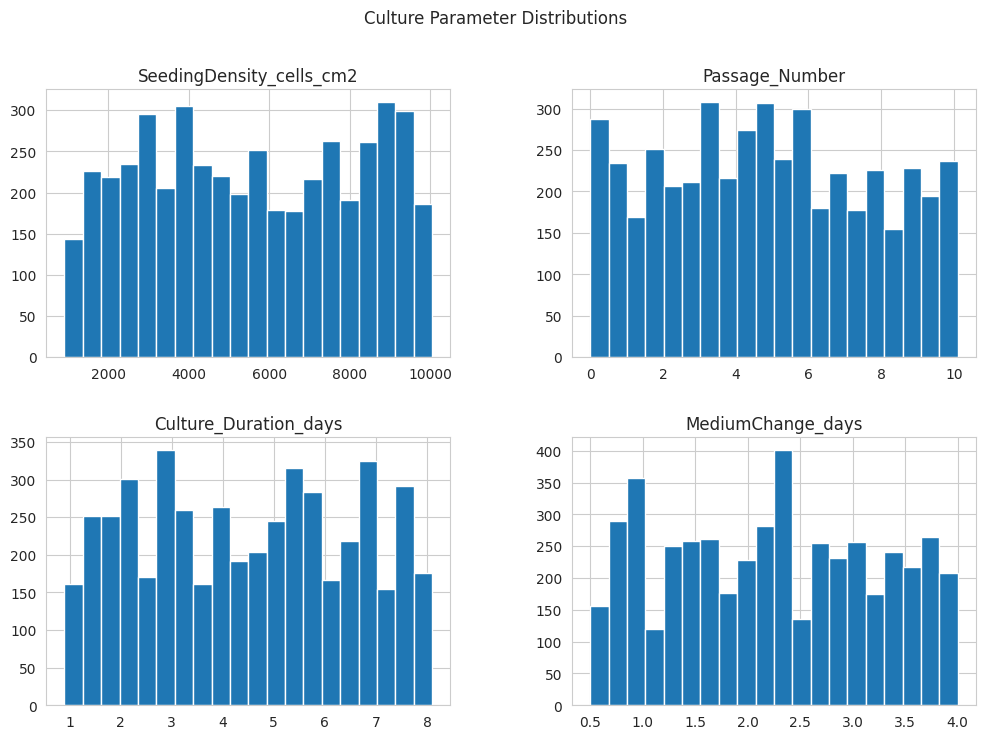

In [11]:
culture_features = [
'SeedingDensity_cells_cm2',
'Passage_Number',
'Culture_Duration_days',
'MediumChange_days'
]

df[culture_features].hist(bins=20, figsize=(12,8))
plt.suptitle("Culture Parameter Distributions")
plt.show()

# 📏Quality Metric Distributions

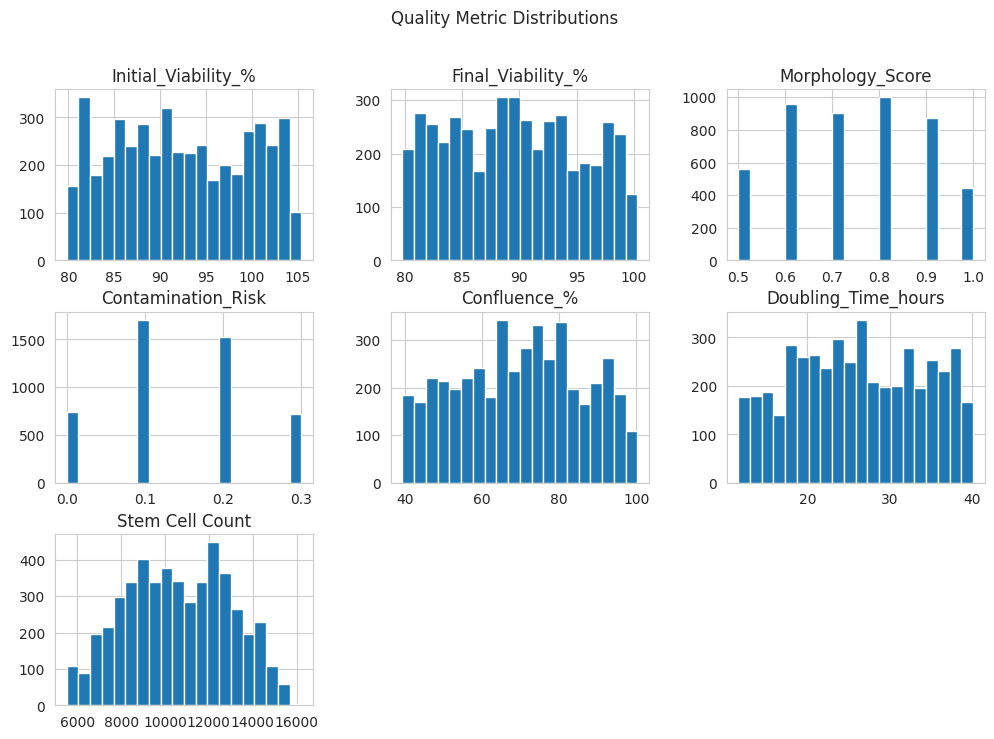

In [13]:
quality_features = [
'Initial_Viability_%',
'Final_Viability_%',
'Morphology_Score',
'Contamination_Risk',
'Confluence_%',
'Doubling_Time_hours',
'Stem Cell Count'
]

df[quality_features].hist(bins=20, figsize=(12,8))
plt.suptitle("Quality Metric Distributions")
plt.show()

# 📦 Boxplots for Outlier Detection

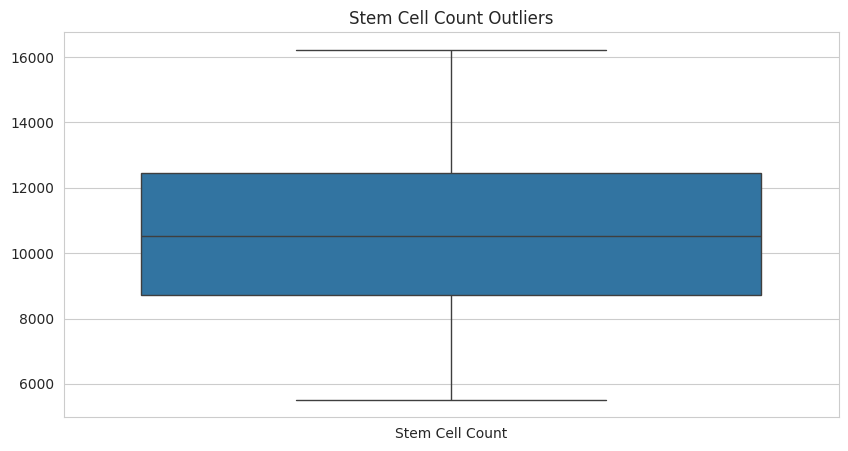

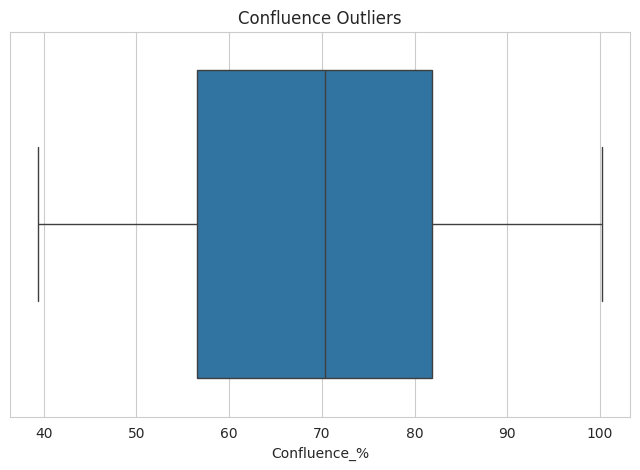

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Stem Cell Count']])
plt.title("Stem Cell Count Outliers")
plt.show()

sns.boxplot(x=df['Confluence_%'])
plt.title("Confluence Outliers")
plt.show()

# 🔬 BIVARIATE ANALYSIS

# 📶Scatter Plots vs Stem Cell Count

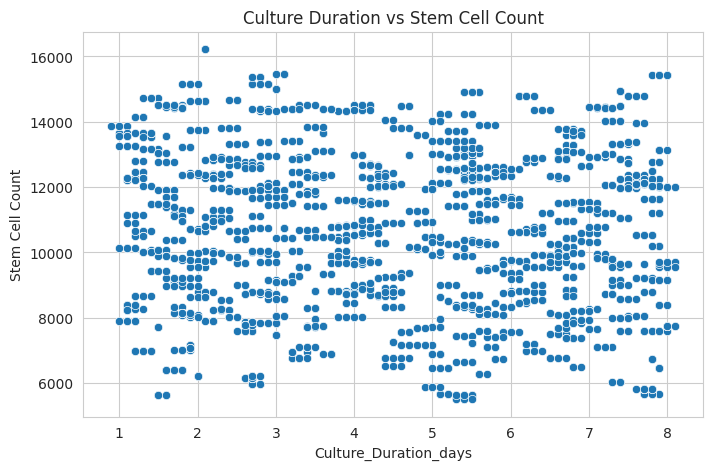

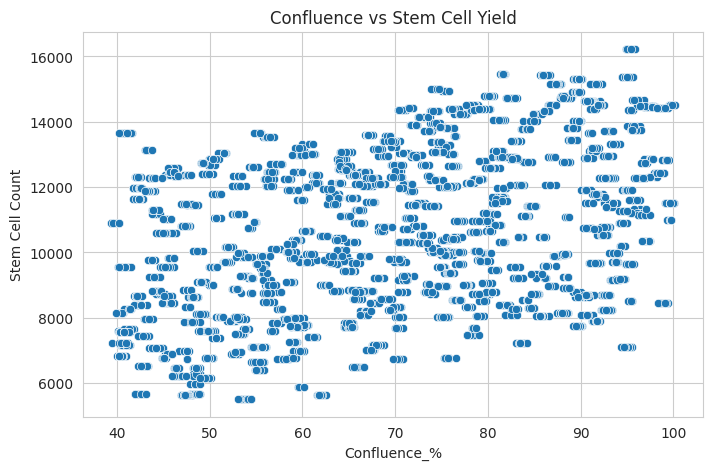

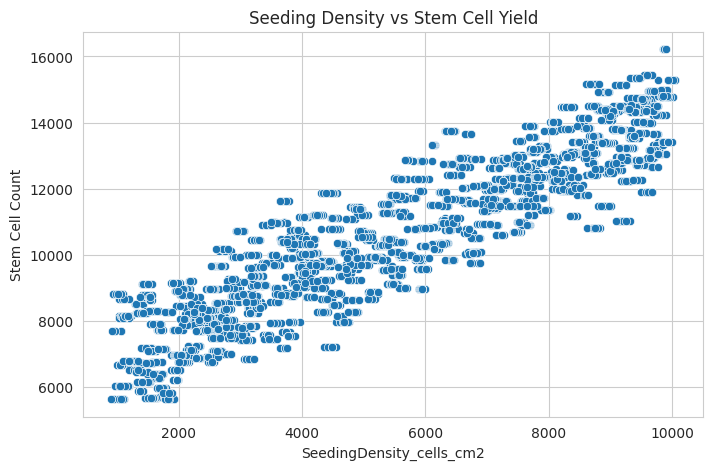

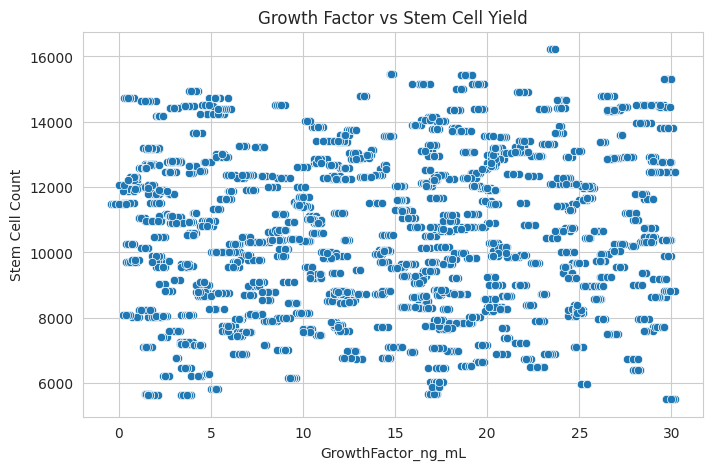

In [17]:
sns.scatterplot(x='Culture_Duration_days', y='Stem Cell Count', data=df)
plt.title("Culture Duration vs Stem Cell Count")
plt.show()
sns.scatterplot(x='Confluence_%', y='Stem Cell Count', data=df)
plt.title("Confluence vs Stem Cell Yield")
plt.show()
sns.scatterplot(x='SeedingDensity_cells_cm2', y='Stem Cell Count', data=df)
plt.title("Seeding Density vs Stem Cell Yield")
plt.show()
sns.scatterplot(x='GrowthFactor_ng_mL', y='Stem Cell Count', data=df)
plt.title("Growth Factor vs Stem Cell Yield")
plt.show()


# 📈 Correlation Analysis

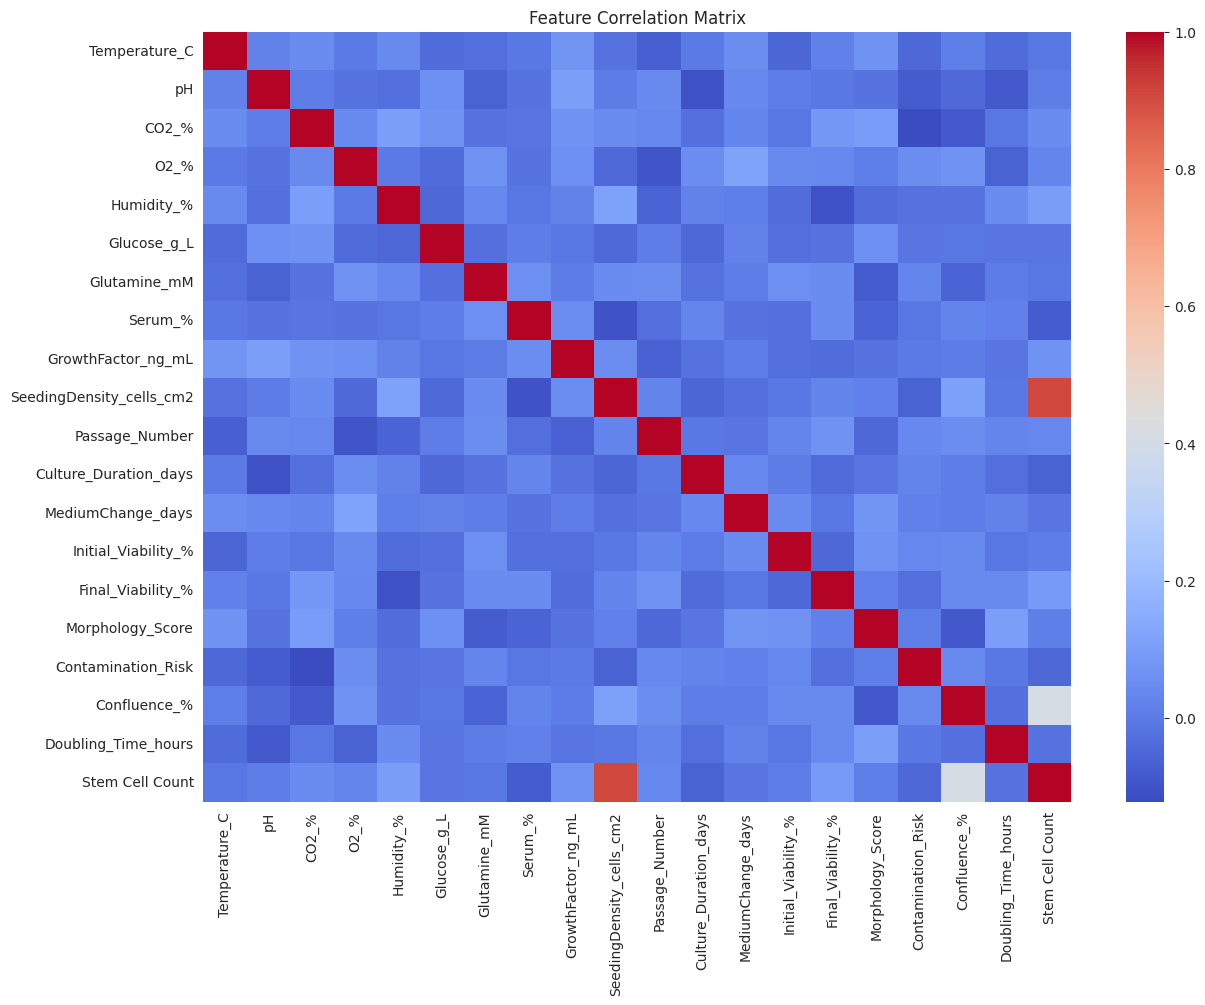

In [18]:
corr = df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm')

plt.title("Feature Correlation Matrix")
plt.show()

# 🎯 Correlation with Target Variable

In [20]:
target_corr = corr['Stem Cell Count'].sort_values(ascending=False)

target_corr

,Stem Cell Count
Stem Cell Count,1.000000
SeedingDensity_cells_cm2,0.911024
Confluence_%,0.412486
Humidity_%,0.101135
Final_Viability_%,0.090332
GrowthFactor_ng_mL,0.064189
CO2_%,0.046346
Passage_Number,0.034577
O2_%,0.028829
Morphology_Score,0.010016


# 🔬 MULTIVARIATE RELATIONSHIPS

# Pairplot of Key Variables

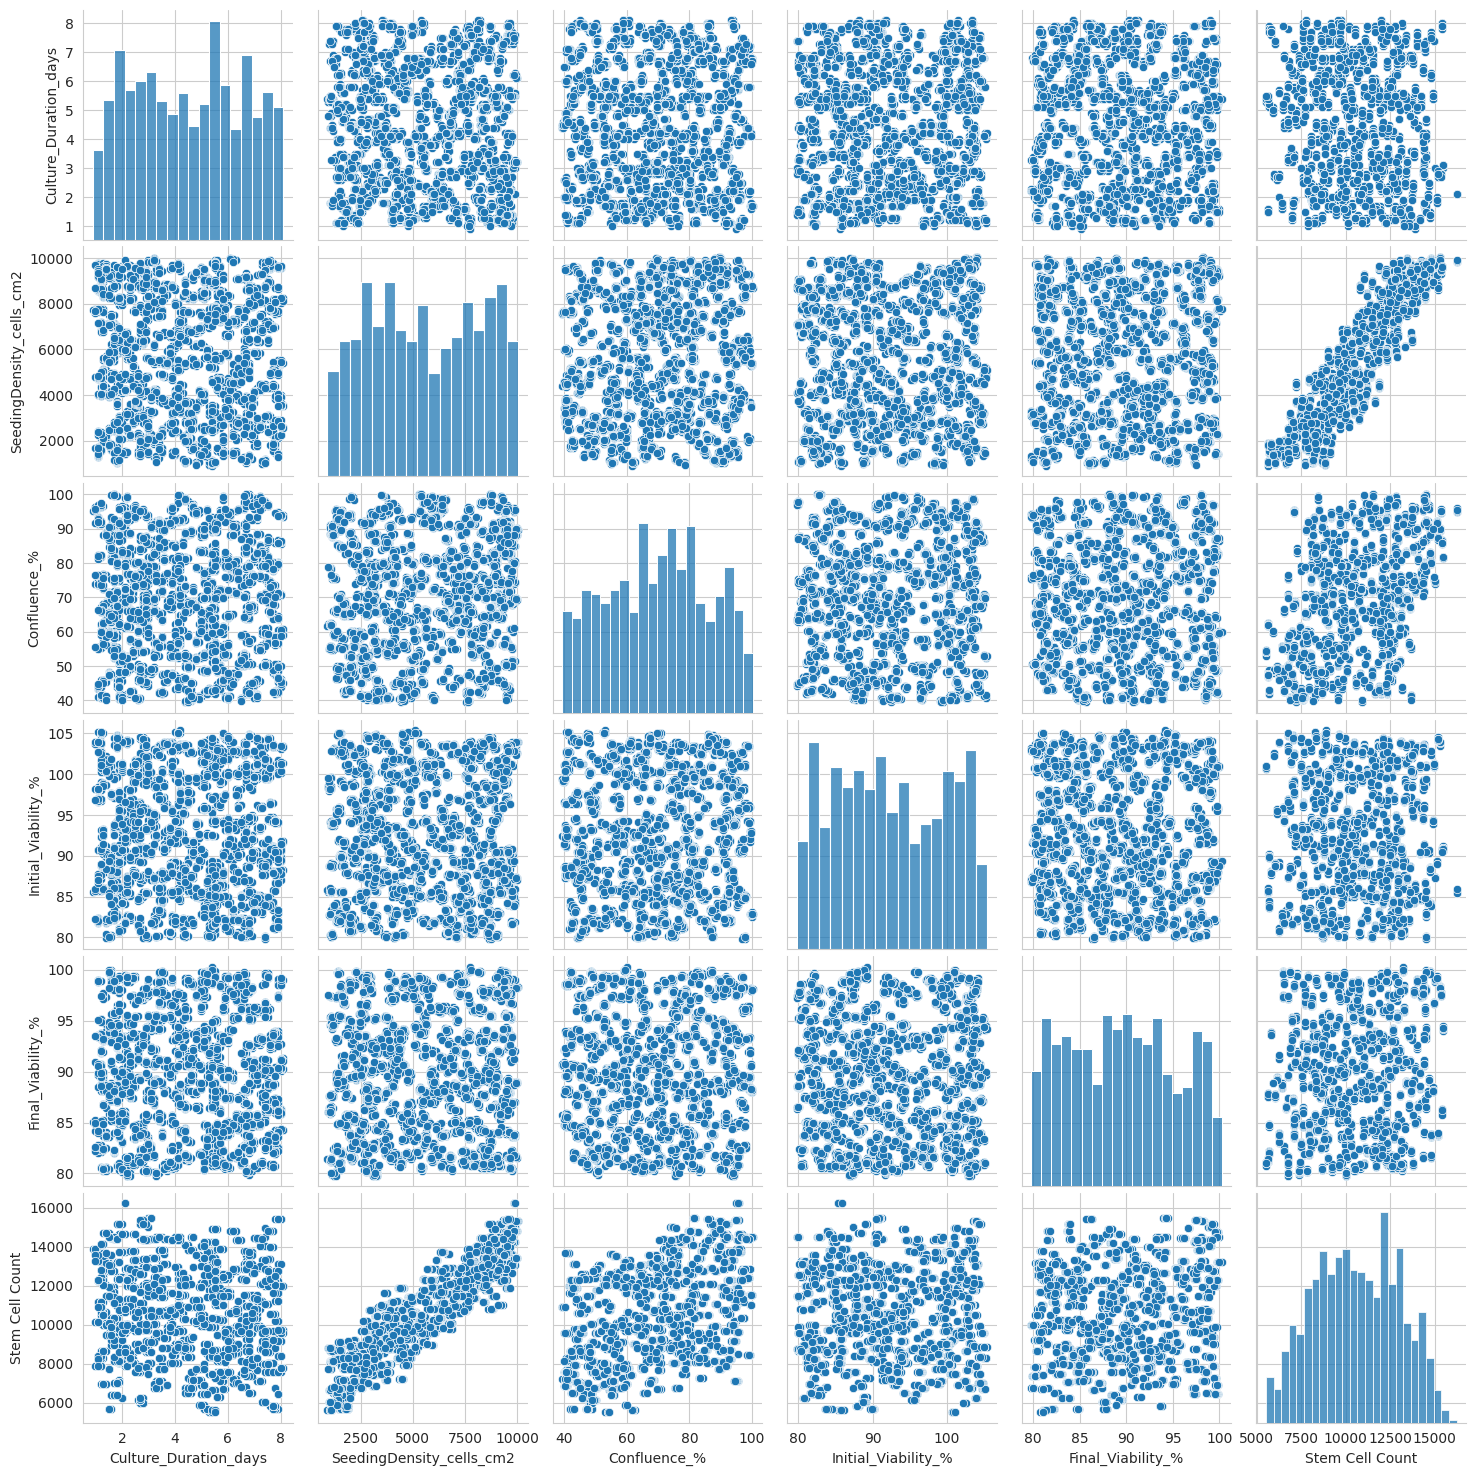

In [22]:
pair_features = [
'Culture_Duration_days',
'SeedingDensity_cells_cm2',
'Confluence_%',
'Initial_Viability_%',
'Final_Viability_%',
'Stem Cell Count'
]

sns.pairplot(df[pair_features])

plt.show()

# 🧬 VIABILITY DYNAMICS

In [23]:
df['Delta_Viability'] = df['Final_Viability_%'] - df['Initial_Viability_%']

df['Delta_Viability'].describe()

,Delta_Viability
count,4389.000000
mean,-2.850718
std,9.423315
min,-24.200000
25%,-9.900000
50%,-2.900000
75%,3.900000
max,18.300000


# Distribution of ΔViability

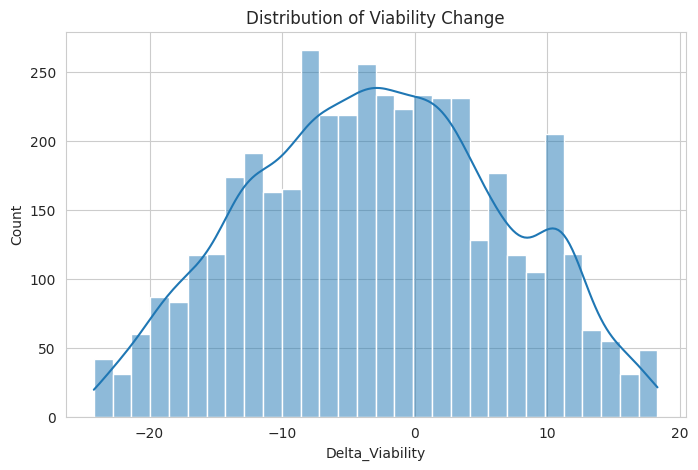

In [24]:
sns.histplot(df['Delta_Viability'], bins=30, kde=True)

plt.title("Distribution of Viability Change")
plt.show()

# ΔViability vs Culture Duration

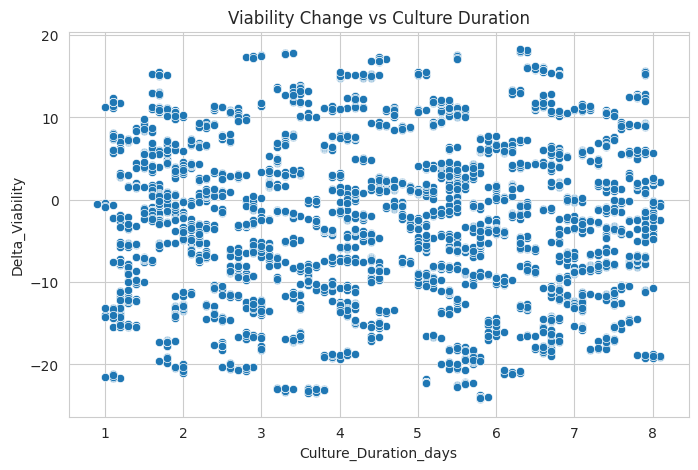

In [25]:
sns.scatterplot(
    x='Culture_Duration_days',
    y='Delta_Viability',
    data=df
)

plt.title("Viability Change vs Culture Duration")
plt.show()

# 🔬 Confluence vs Doubling Time

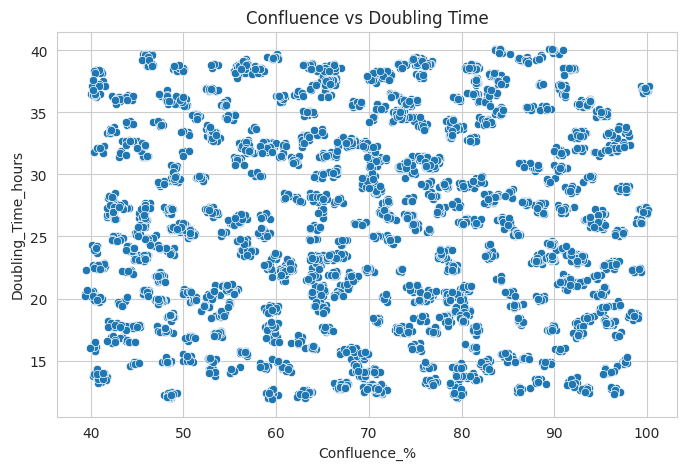

In [26]:
sns.scatterplot(
    x='Confluence_%',
    y='Doubling_Time_hours',
    data=df
)

plt.title("Confluence vs Doubling Time")
plt.show()

# 📊 Stratified Yield Analysis

In [28]:
df['Duration_Group'] = pd.cut(
    df['Culture_Duration_days'],
    bins=[2,3,4,5,6],
    labels=['2-3','3-4','4-5','>5']
)

df.groupby('Duration_Group')['Stem Cell Count'].mean()

/tmp/ipykernel_204/2988223108.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Duration_Group')['Stem Cell Count'].mean()


,Stem Cell Count
Duration_Group,
2-3,10903.105964
3-4,10686.303595
4-5,10379.727717
>5,10501.864346


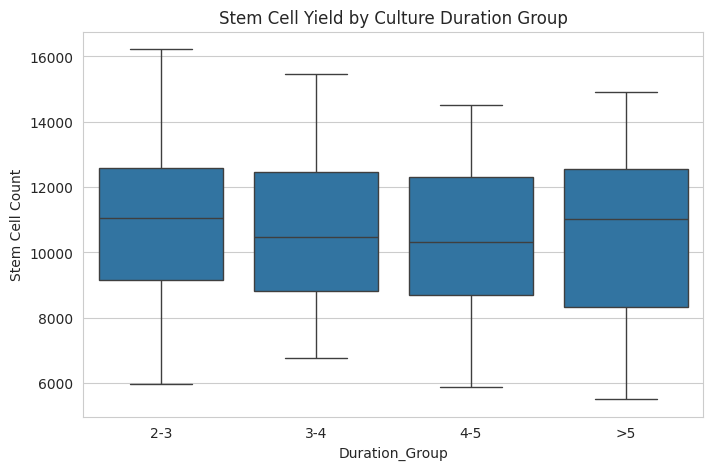

In [30]:
#Visualization

sns.boxplot(
    x='Duration_Group',
    y='Stem Cell Count',
    data=df
)

plt.title("Stem Cell Yield by Culture Duration Group")
plt.show()

# 🚀 Final Output of EDA

This notebook provides:

✔ Dataset validation

✔ Outlier detection

✔ Biological range validation

✔ Feature distribution analysis

✔ Parameter relationships

✔ Correlation heatmap

✔ Viability dynamics analysis

✔ Stratified yield analysis


These results directly support machine learning modeling for predicting stem cell yield.